# 03 - DenseNet-121 for NIH Chest X-Ray Classification

Multi-label classification of 14 diseases using DenseNet-121 with:
- CLAHE preprocessing + Adaptive Lung Crop
- Focal Loss with Label Smoothing
- GroupKFold cross-validation by Patient ID
- Per-class optimal threshold tuning

## 1. Setup & Imports

In [1]:
import os
from glob import glob
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.model_selection import GroupKFold

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.amp import autocast, GradScaler
from torchvision import transforms as T, models

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)

# CUDA optimizations
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 2. Configuration

In [2]:
# ==================== PATHS ====================
ROOT = Path('/kaggle/input/datasets/organizations/nih-chest-xrays/data')
CSV_PATH = ROOT / 'Data_Entry_2017.csv'
TRAIN_SPLIT = Path('/kaggle/input/datasets/zoey041/nih-subset/train_subset.txt')
TEST_SPLIT = Path('/kaggle/input/datasets/zoey041/nih-subset/test_subset.txt')
OUT_DIR = Path('/kaggle/working/output')
ENS_DIR = OUT_DIR / 'ensemble_inputs'
ENS_DIR.mkdir(parents=True, exist_ok=True)

# Get all image paths
all_image_paths = {
    os.path.basename(p): p 
    for p in glob(f'{ROOT}/images_*/images/*.png')
}
print(f'Total images found: {len(all_image_paths)}')

# ==================== DISEASE LABELS ====================
DISEASES = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

# ==================== MODEL CONFIG ====================
MODEL_KEY = 'densenet'
MODEL_NAME = 'densenet121'
IMAGE_SIZE = 256
DROPOUT_RATE = 0.3

# ==================== TRAINING CONFIG ====================
BATCH_SIZE = 32
NUM_WORKERS = 4
LR = 5e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1

# Focal Loss parameters
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 1.0

# Training modes
EARLY_EPOCHS = 15
EARLY_PATIENCE = 5
FULL_EPOCHS = 20

print('\n=== Training Configuration ===')
print(f'Model: {MODEL_NAME}')
print(f'Image size: {IMAGE_SIZE}x{IMAGE_SIZE}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Learning rate: {LR}')
print(f'Weight decay: {WEIGHT_DECAY}')
print(f'Label smoothing: {LABEL_SMOOTHING}')
print(f'Focal Loss: alpha={FOCAL_ALPHA}, gamma={FOCAL_GAMMA}')

Total images found: 112120

=== Training Configuration ===
Model: densenet121
Image size: 256x256
Batch size: 32
Learning rate: 0.0005
Weight decay: 0.0001
Label smoothing: 0.1
Focal Loss: alpha=1.0, gamma=2.0


## 3. Load Data

In [3]:
# Load labels
labels = pd.read_csv(CSV_PATH)
labels = labels.rename(columns={
    'Image Index': 'Image_index', 
    'Finding Labels': 'Finding_labels', 
    'Patient ID': 'Patient_id'
})

# Create binary labels for each disease
label_cols = labels['Finding_labels'].str.get_dummies(sep='|')[DISEASES]
labels = pd.concat([labels[['Image_index', 'Patient_id']], label_cols], axis=1)

# Load train/test splits
with open(TRAIN_SPLIT, 'r') as f:
    train_list = f.read().split('\n')
with open(TEST_SPLIT, 'r') as f:
    test_list = f.read().split('\n')

train_labels = labels[labels['Image_index'].isin(train_list)].copy()
test_labels = labels[labels['Image_index'].isin(test_list)].copy()

print('=== Dataset Information ===')
print(f'Train: {len(train_labels)} images, {train_labels["Patient_id"].nunique()} patients')
print(f'Test: {len(test_labels)} images, {test_labels["Patient_id"].nunique()} patients')

=== Dataset Information ===
Train: 15155 images, 5000 patients
Test: 4788 images, 500 patients


## 4. Preprocessing

In [4]:
class AdaptiveLungCropCLAHE:
    """
    Adaptive preprocessing for chest X-rays:
    1. Convert to grayscale
    2. Apply Otsu's thresholding to find lung region
    3. Crop to lung bounding box with padding
    4. Apply CLAHE for contrast enhancement
    5. Resize to target size
    """
    def __init__(self, out_size, clip_limit=2.0, pad=12):
        self.out_size = out_size
        self.clip_limit = clip_limit
        self.pad = pad

    def __call__(self, img):
        # Convert to grayscale numpy array
        arr = np.array(img.convert('L'))
        
        # Find lung region using Otsu's thresholding
        blur = cv2.GaussianBlur(arr, (5, 5), 0)
        _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        # Crop to bounding box
        ys, xs = np.where(mask > 0)
        if len(xs) > 0 and len(ys) > 0:
            x1 = max(xs.min() - self.pad, 0)
            x2 = min(xs.max() + self.pad, arr.shape[1] - 1)
            y1 = max(ys.min() - self.pad, 0)
            y2 = min(ys.max() + self.pad, arr.shape[0] - 1)
            arr = arr[y1:y2+1, x1:x2+1]
        
        # Apply CLAHE
        clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=(8, 8))
        arr = clahe.apply(arr)
        
        # Resize
        arr = cv2.resize(arr, (self.out_size, self.out_size), interpolation=cv2.INTER_AREA)
        
        # Convert back to RGB PIL Image
        return Image.fromarray(cv2.cvtColor(arr, cv2.COLOR_GRAY2RGB))

In [5]:
class XrayDataset(Dataset):
    """Dataset class for chest X-ray images."""
    
    def __init__(self, data, image_paths, transform):
        self.data = data.reset_index(drop=True)
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_name = row['Image_index']
        img_path = self.image_paths[img_name]
        
        # Load and transform image
        img = Image.open(img_path).convert('RGB')
        img = self.transform(img)
        
        # Get labels
        label = row[DISEASES].values.astype(np.float32)
        
        return img, label

In [6]:
def build_transforms():
    """Build train and validation transforms."""
    adaptive = AdaptiveLungCropCLAHE(IMAGE_SIZE)
    
    train_transform = T.Compose([
        adaptive,
        # T.Resize((IMAGE_SIZE, IMAGE_SIZE)), 
        T.RandomRotation(15),
        T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
        T.ColorJitter(brightness=0.15, contrast=0.15),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    
    valid_transform = T.Compose([
        adaptive,
        # T.Resize((IMAGE_SIZE, IMAGE_SIZE)), 
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    
    return train_transform, valid_transform

## 5. Model Architecture

In [7]:
class ImprovedDenseNet(nn.Module):
    """
    DenseNet-121 with custom classifier head.
    
    Architecture:
    - Pretrained DenseNet-121 backbone (denseblock1-2 frozen)
    - Custom classifier: Linear(1024->512) -> BN -> ReLU -> Dropout
                       -> Linear(512->256) -> BN -> ReLU -> Dropout
                       -> Linear(256->14)
    """
    
    def __init__(self, num_classes=14, dropout_rate=0.3):
        super().__init__()
        
        # Load pretrained backbone
        self.backbone = models.densenet121(
            weights=models.DenseNet121_Weights.DEFAULT
        )
        
        # Freeze early layers (denseblock1 and denseblock2)
        for name, param in self.backbone.named_parameters():
            if any(f'denseblock{i}' in name for i in [1, 2]):
                param.requires_grad = False
        
        # Get number of features from original classifier
        num_features = self.backbone.classifier.in_features  # 1024
        
        # Replace classifier with custom head
        self.backbone.classifier = nn.Sequential(
            # First block: 1024 -> 512
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            
            # Second block: 512 -> 256
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.6),
            
            # Output layer
            nn.Linear(256, num_classes)
        )
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        """Initialize classifier weights using Kaiming initialization."""
        for m in self.backbone.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        return self.backbone(x)


# Test model
model = ImprovedDenseNet(num_classes=len(DISEASES), dropout_rate=DROPOUT_RATE)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Model: {MODEL_NAME}')
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Frozen parameters: {total_params - trainable_params:,}')
del model

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 176MB/s]


Model: densenet121
Total parameters: 7,615,118
Trainable parameters: 6,360,398
Frozen parameters: 1,254,720


## 6. Loss Function

In [8]:
class FocalLoss(nn.Module):
    """
    Focal Loss for handling class imbalance.
    
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    
    Args:
        alpha: Weighting factor (default: 1.0)
        gamma: Focusing parameter - higher values focus more on hard examples (default: 2.0)
        pos_weight: Per-class positive weights (optional)
        label_smoothing: Smoothing factor for noisy labels (default: 0.0)
    """
    
    def __init__(self, alpha=1.0, gamma=2.0, pos_weight=None, label_smoothing=0.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight
        self.label_smoothing = label_smoothing
    
    def forward(self, inputs, targets):
        # Apply label smoothing
        if self.label_smoothing > 0:
            targets = targets * (1 - self.label_smoothing) + self.label_smoothing / 2
        
        # Compute BCE loss
        bce = F.binary_cross_entropy_with_logits(
            inputs, targets, 
            pos_weight=self.pos_weight, 
            reduction='none'
        )
        
        # Compute focal weight
        pt = torch.exp(-bce)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce
        
        return focal_loss.mean()


def compute_pos_weights(df, disease_cols):
    """
    Compute positive class weights for imbalanced data.
    Weight = negative_count / positive_count (capped at 50)
    """
    pos_counts = df[disease_cols].sum().values
    neg_counts = len(df) - pos_counts
    pos_weights = neg_counts / (pos_counts + 1e-6)
    return torch.tensor(np.clip(pos_weights, 1.0, 50.0), dtype=torch.float32)


# Compute and display class weights
pos_weights = compute_pos_weights(train_labels, DISEASES).to(DEVICE)
print('\n=== Positive Class Weights ===')
for disease, weight in zip(DISEASES, pos_weights.cpu().numpy()):
    print(f'{disease:20s}: {weight:.1f}')


=== Positive Class Weights ===
Atelectasis         : 9.6
Cardiomegaly        : 49.7
Consolidation       : 27.6
Edema               : 50.0
Effusion            : 8.8
Emphysema           : 50.0
Fibrosis            : 50.0
Hernia              : 50.0
Infiltration        : 5.2
Mass                : 20.1
Nodule              : 17.5
Pleural_Thickening  : 36.7
Pneumonia           : 50.0
Pneumothorax        : 29.2


## 7. Training Functions

In [9]:
def macro_auc(y_true, y_prob):
    """Calculate macro-averaged AUC-ROC."""
    try:
        return float(roc_auc_score(y_true, y_prob, average='macro'))
    except:
        return 0.0


def evaluate_epoch(model, loader, criterion):
    """Evaluate model on a dataloader."""
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE).float()
            
            with autocast('cuda', enabled=torch.cuda.is_available()):
                logits = model(images)
                loss = criterion(logits, labels)
            
            total_loss += loss.item()
            all_preds.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    y_true = np.vstack(all_labels)
    y_prob = np.vstack(all_preds)
    avg_loss = total_loss / len(loader)
    auc = macro_auc(y_true, y_prob)
    
    return avg_loss, auc, y_true, y_prob

In [10]:
PIN_MEMORY = torch.cuda.is_available()

def run_single_fold(df_train, df_val, fold_idx, mode_name, max_epochs, patience):
    """
    Train model for a single fold.
    
    Args:
        df_train: Training dataframe
        df_val: Validation dataframe
        fold_idx: Fold number (1-indexed)
        mode_name: 'early_stop' or 'full_epoch'
        max_epochs: Maximum number of epochs
        patience: Early stopping patience
    
    Returns:
        model: Trained model with best weights
        best_auc: Best validation AUC
        y_true_val: Validation labels
        y_prob_val: Validation predictions
    """
    print(f'\n{"="*50}')
    print(f'Fold {fold_idx} | Mode: {mode_name} | Epochs: {max_epochs}')
    print(f'{"="*50}')
    
    # Build transforms and datasets
    train_tf, valid_tf = build_transforms()
    train_ds = XrayDataset(df_train, all_image_paths, train_tf)
    val_ds = XrayDataset(df_val, all_image_paths, valid_tf)
    
    # Create dataloaders
    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=True if NUM_WORKERS > 0 else False
    )
    val_loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=True if NUM_WORKERS > 0 else False
    )
    
    print(f'Train size: {len(train_ds)}, Val size: {len(val_ds)}')
    
    # Initialize model
    model = ImprovedDenseNet(num_classes=len(DISEASES), dropout_rate=DROPOUT_RATE).to(DEVICE)
    
    # Loss function (using Focal Loss without pos_weight)
    criterion = FocalLoss(
        alpha=FOCAL_ALPHA, 
        gamma=FOCAL_GAMMA, 
        pos_weight=None,  # Using label smoothing instead
        label_smoothing=LABEL_SMOOTHING
    )
    
    # Optimizer
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    
    # Scheduler: CosineAnnealingWarmRestarts
    iters_per_epoch = len(train_loader)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=iters_per_epoch * 2, T_mult=2, eta_min=1e-6
    )
    
    # Mixed precision scaler
    scaler = GradScaler('cuda') if torch.cuda.is_available() else None
    
    # Training state
    best_auc = -1.0
    best_state = None
    best_val_pred = None
    wait = 0
    
    # Checkpoint directory
    ckpt_dir = OUT_DIR / MODEL_KEY / mode_name
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = ckpt_dir / f'fold_{fold_idx}_checkpoint.pt'
    start_epoch = 0
    
    # Resume from checkpoint if exists
    if ckpt_path.exists():
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        start_epoch = ckpt['epoch'] + 1
        best_auc = ckpt['val_auc']
        wait = ckpt.get('wait', 0)
        print(f'Resumed from epoch {start_epoch}, AUC={best_auc:.4f}')
    
    # Training loop
    for epoch in range(start_epoch, max_epochs):
        # ========== Training ==========
        model.train()
        train_loss = 0.0
        
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{max_epochs} [Train]', leave=False)
        for batch_idx, (images, labels) in enumerate(pbar):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE).float()
            
            optimizer.zero_grad(set_to_none=True)
            
            with autocast('cuda', enabled=torch.cuda.is_available()):
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            
            # Update scheduler per iteration
            scheduler.step(epoch + batch_idx / iters_per_epoch)
            
            train_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        avg_train_loss = train_loss / len(train_loader)
        
        # ========== Validation ==========
        val_loss, val_auc, y_true_val, y_prob_val = evaluate_epoch(model, val_loader, criterion)
        val_acc = ((y_prob_val >= 0.5) == y_true_val).mean() * 100
        
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1}/{max_epochs}: '
              f'Train Loss = {avg_train_loss:.4f} | '
              f'Val Loss = {val_loss:.4f} | '
              f'Val Acc = {val_acc:.2f}% | '
              f'Val AUC = {val_auc*100:.2f}% | '
              f'LR = {current_lr:.2e}')
        
        # Save best model
        if val_auc > best_auc:
            print(f'=> Val AUC improved ({best_auc*100:.2f}% -> {val_auc*100:.2f}%). Saving model...')
            best_auc = val_auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_val_pred = y_prob_val
            wait = 0
            
            # Save checkpoint
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_auc': val_auc,
                'wait': wait
            }, ckpt_path)
        else:
            wait += 1
        
        # Early stopping
        if mode_name == 'early_stop' and wait >= patience:
            print(f'Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)')
            break
    
    # Load best weights
    if best_state:
        model.load_state_dict(best_state)
    
    if best_val_pred is None:
        _, best_auc, y_true_val, best_val_pred = evaluate_epoch(model, val_loader, criterion)
    
    return model, best_auc, y_true_val, best_val_pred

## 8. Run Training

In [11]:
# Define training modes
RUN_MODES = [
    {'name': 'early_stop', 'epochs': EARLY_EPOCHS, 'patience': EARLY_PATIENCE},
    {'name': 'full_epoch', 'epochs': FULL_EPOCHS, 'patience': FULL_EPOCHS},
]

# GroupKFold split by Patient ID
gkf = GroupKFold(n_splits=3)
groups = train_labels['Patient_id'].values

# Track best mode
best_mode_name = None
best_mode_auc = -1.0
best_mode_artifacts = None

for mode in RUN_MODES:
    mode_name = mode['name']
    print(f'\n{"="*60}')
    print(f'MODE: {mode_name.upper()} | Epochs: {mode["epochs"]}')
    print(f'{"="*60}')
    
    # Initialize arrays for out-of-fold predictions
    fold_oof = np.zeros((len(train_labels), len(DISEASES)), dtype=np.float32)
    fold_test_probs = []
    fold_aucs = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(gkf.split(train_labels, groups=groups), 1):
        print(f'\n--- Fold {fold_idx}/3 ---')
        
        df_train = train_labels.iloc[train_idx].copy()
        df_val = train_labels.iloc[val_idx].copy()
        
        # Train fold
        model, fold_auc, _, y_prob_val = run_single_fold(
            df_train, df_val, fold_idx, mode_name, 
            mode['epochs'], mode['patience']
        )
        
        fold_aucs.append(fold_auc)
        fold_oof[val_idx] = y_prob_val.astype(np.float32)
        
        # Predict on test set
        _, valid_tf = build_transforms()
        test_ds = XrayDataset(test_labels, all_image_paths, valid_tf)
        test_loader = DataLoader(
            test_ds, batch_size=BATCH_SIZE, shuffle=False,
            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
        )
        
        model.eval()
        test_preds = []
        with torch.no_grad():
            for images, _ in test_loader:
                with autocast('cuda', enabled=torch.cuda.is_available()):
                    preds = torch.sigmoid(model(images.to(DEVICE)))
                test_preds.append(preds.cpu().numpy())
        fold_test_probs.append(np.vstack(test_preds))
        
        # Save fold model
        save_path = OUT_DIR / MODEL_KEY / mode_name / f'fold_{fold_idx}.pt'
        torch.save(model.state_dict(), save_path)
        print(f'Fold {fold_idx} complete | AUC = {fold_auc*100:.2f}%')
    
    # Calculate OOF AUC
    mode_auc = macro_auc(train_labels[DISEASES].values, fold_oof)
    print(f'\n[{mode_name}] OOF AUC = {mode_auc*100:.2f}%')
    print(f'Fold AUCs: {[f"{a*100:.2f}%" for a in fold_aucs]}')
    
    # Update best mode
    if mode_auc > best_mode_auc:
        best_mode_auc = mode_auc
        best_mode_name = mode_name
        best_mode_artifacts = {
            'oof': fold_oof,
            'test_probs': np.mean(np.stack(fold_test_probs), axis=0),
            'fold_aucs': fold_aucs
        }

print(f'\n{"="*60}')
print(f'BEST MODE: {best_mode_name} | OOF AUC = {best_mode_auc*100:.2f}%')
print(f'{"="*60}')


MODE: EARLY_STOP | Epochs: 15

--- Fold 1/3 ---

Fold 1 | Mode: early_stop | Epochs: 15
Train size: 10103, Val size: 5052


Epoch 1/15 [Train]:   0%|          | 0/316 [00:00<?, ?it/s]

Epoch 1/15: Train Loss = 0.3154 | Val Loss = 0.4177 | Val Acc = 95.36% | Val AUC = 63.48% | LR = 5.00e-04
=> Val AUC improved (-100.00% -> 63.48%). Saving model...


Epoch 2/15 [Train]:   0%|          | 0/316 [00:00<?, ?it/s]

Epoch 2/15: Train Loss = 0.0957 | Val Loss = 0.1332 | Val Acc = 95.37% | Val AUC = 69.75% | LR = 5.00e-04
=> Val AUC improved (63.48% -> 69.75%). Saving model...


...

Epoch 18/20: Train Loss = 0.0643 | Val Loss = 0.0554 | Val Acc = 95.62% | Val AUC = 73.14% | LR = 4.99e-04
=> Val AUC improved (72.29% -> 73.14%). Saving model...


Epoch 19/20 [Train]:   0%|          | 0/316 [00:00<?, ?it/s]

Epoch 19/20: Train Loss = 0.0691 | Val Loss = 0.1472 | Val Acc = 95.58% | Val AUC = 71.95% | LR = 4.99e-04


Epoch 20/20 [Train]:   0%|          | 0/316 [00:00<?, ?it/s]

Epoch 20/20: Train Loss = 0.0626 | Val Loss = 0.0628 | Val Acc = 95.57% | Val AUC = 71.32% | LR = 4.99e-04
Fold 3 complete | AUC = 73.14%

[full_epoch] OOF AUC = 71.84%
Fold AUCs: ['72.70%', '71.49%', '73.14%']

BEST MODE: full_epoch | OOF AUC = 71.84%


## 9. Out-of-Fold Results

In [12]:
# Calculate per-class metrics on OOF predictions
y_true = train_labels[DISEASES].values.astype(np.int32)
y_prob = best_mode_artifacts['oof']
y_pred = (y_prob >= 0.5).astype(np.int32)

results = []
for i, disease in enumerate(DISEASES):
    yt = y_true[:, i]
    yp = y_prob[:, i]
    yb = y_pred[:, i]
    
    try:
        auc = roc_auc_score(yt, yp)
    except:
        auc = 0.0
    
    results.append({
        'Disease': disease,
        'AUC': round(auc * 100, 2),
        'F1': round(f1_score(yt, yb, zero_division=0) * 100, 2),
        'Precision': round(precision_score(yt, yb, zero_division=0) * 100, 2),
        'Recall': round(recall_score(yt, yb, zero_division=0) * 100, 2)
    })

report_df = pd.DataFrame(results).sort_values('AUC', ascending=False)

print('\n=== Out-of-Fold Performance (Best Mode) ===')
print(report_df.to_string(index=False))
print(f'\nMacro AUC: {report_df["AUC"].mean():.2f}%')
print(f'Macro F1: {report_df["F1"].mean():.2f}%')


=== Out-of-Fold Performance (Best Mode) ===
           Disease   AUC    F1  Precision  Recall
          Effusion 85.20 28.34      65.03   18.12
             Edema 83.11  0.00       0.00    0.00
     Consolidation 77.68  0.00       0.00    0.00
         Emphysema 75.28  0.00       0.00    0.00
       Atelectasis 73.71  0.00       0.00    0.00
      Pneumothorax 72.54  0.00       0.00    0.00
            Hernia 71.41  0.00       0.00    0.00
      Cardiomegaly 70.24  0.00       0.00    0.00
              Mass 68.64  0.00       0.00    0.00
          Fibrosis 67.98  0.00       0.00    0.00
Pleural_Thickening 67.11  0.00       0.00    0.00
      Infiltration 65.02  0.16      33.33    0.08
         Pneumonia 64.56  0.00       0.00    0.00
            Nodule 63.29  0.00       0.00    0.00

Macro AUC: 71.84%
Macro F1: 2.04%


In [13]:
# Save OOF predictions for ensemble
oof_df = pd.DataFrame({
    'Image_index': train_labels['Image_index'],
    **{d: y_prob[:, i] for i, d in enumerate(DISEASES)}
})
oof_df.to_csv(ENS_DIR / f'{MODEL_KEY}_oof_probs.csv', index=False)

# Save test predictions
test_probs = best_mode_artifacts['test_probs']
test_df = pd.DataFrame({
    'Image_index': test_labels['Image_index'],
    **{d: test_probs[:, i] for i, d in enumerate(DISEASES)}
})
test_df.to_csv(ENS_DIR / f'{MODEL_KEY}_test_probs.csv', index=False)

# Save summary
summary = {
    'model_key': MODEL_KEY,
    'best_mode': best_mode_name,
    'oof_auc': float(best_mode_auc),
    'fold_aucs': [float(x) for x in best_mode_artifacts['fold_aucs']]
}
with open(ENS_DIR / f'{MODEL_KEY}_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Save metrics
report_df.to_csv(ENS_DIR / f'{MODEL_KEY}_metrics.csv', index=False)

print(f'Saved predictions to {ENS_DIR}')

Saved predictions to /kaggle/working/output/ensemble_inputs


## 10. Optimal Threshold Tuning

In [14]:
def find_optimal_thresholds(y_true, y_prob, disease_cols, min_precision=0.15):
    """
    Find optimal threshold for each class to maximize F1-score
    while maintaining minimum precision.
    
    Args:
        y_true: Ground truth labels
        y_prob: Predicted probabilities
        disease_cols: List of disease names
        min_precision: Minimum acceptable precision (default: 15%)
    
    Returns:
        optimal_thresholds: Dictionary of thresholds per class
        results_df: DataFrame with threshold results
    """
    optimal_thresholds = {}
    results = []
    
    for i, col in enumerate(disease_cols):
        yt = y_true[:, i]
        yp = y_prob[:, i]
        
        best_f1 = 0
        best_threshold = 0.5
        best_metrics = {}
        
        # Search thresholds from 0.1 to 0.6
        for thresh in np.arange(0.1, 0.61, 0.02):
            pred_binary = (yp >= thresh).astype(int)
            
            precision = precision_score(yt, pred_binary, zero_division=0)
            recall = recall_score(yt, pred_binary, zero_division=0)
            f1 = f1_score(yt, pred_binary, zero_division=0)
            
            if precision >= min_precision and f1 > best_f1:
                best_f1 = f1
                best_threshold = thresh
                best_metrics = {'precision': precision, 'recall': recall, 'f1': f1}
        
        optimal_thresholds[col] = best_threshold
        results.append({
            'Disease': col,
            'Threshold': round(best_threshold, 2),
            'F1': round(best_metrics.get('f1', 0) * 100, 2),
            'Precision': round(best_metrics.get('precision', 0) * 100, 2),
            'Recall': round(best_metrics.get('recall', 0) * 100, 2)
        })
    
    return optimal_thresholds, pd.DataFrame(results)

In [15]:
def evaluate_model(dataloader, model, disease_cols, threshold=0.5, thresholds_dict=None, dataset_name='Dataset'):
    """
    Comprehensive model evaluation.
    
    Args:
        dataloader: DataLoader for evaluation
        model: Trained model
        disease_cols: List of disease names
        threshold: Fixed threshold (used if thresholds_dict is None)
        thresholds_dict: Dictionary of per-class thresholds
        dataset_name: Name for logging
    
    Returns:
        results_df: DataFrame with per-class metrics
        all_preds: Predicted probabilities
        all_labels: Ground truth labels
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f'Evaluating {dataset_name}'):
            with autocast('cuda', enabled=torch.cuda.is_available()):
                preds = torch.sigmoid(model(images.to(DEVICE)))
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.numpy())
    
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    # Calculate per-class metrics
    results = []
    for i, col in enumerate(disease_cols):
        t = thresholds_dict.get(col, threshold) if thresholds_dict else threshold
        pred_binary = (all_preds[:, i] >= t).astype(int)
        true_labels = all_labels[:, i].astype(int)
        
        tp = ((pred_binary == 1) & (true_labels == 1)).sum()
        tn = ((pred_binary == 0) & (true_labels == 0)).sum()
        fp = ((pred_binary == 1) & (true_labels == 0)).sum()
        fn = ((pred_binary == 0) & (true_labels == 1)).sum()
        
        accuracy = (pred_binary == true_labels).mean() * 100
        
        try:
            auc = roc_auc_score(true_labels, all_preds[:, i]) * 100
        except:
            auc = 0.0
        
        results.append({
            'Disease': col,
            'Threshold': round(t, 2),
            'Accuracy': round(accuracy, 2),
            'AUC-ROC': round(auc, 2),
            'Precision': round(precision_score(true_labels, pred_binary, zero_division=0) * 100, 2),
            'Recall': round(recall_score(true_labels, pred_binary, zero_division=0) * 100, 2),
            'F1-Score': round(f1_score(true_labels, pred_binary, zero_division=0) * 100, 2),
            'TP': int(tp),
            'TN': int(tn),
            'FP': int(fp),
            'FN': int(fn),
            'Total_Pos': int(true_labels.sum()),
            'Pred_Pos': int(pred_binary.sum())
        })
    
    df = pd.DataFrame(results)
    
    # Print summary
    print(f'\n{"="*60}')
    print(f'{dataset_name.upper()} RESULTS')
    print(f'{"="*60}')
    print(f'Threshold: {"Per-class optimal" if thresholds_dict else f"Fixed ({threshold})"}')
    print(f'Mean AUC: {df["AUC-ROC"].mean():.2f}%')
    print(f'Mean F1: {df["F1-Score"].mean():.2f}%')
    print(f'Mean Precision: {df["Precision"].mean():.2f}%')
    print(f'Mean Recall: {df["Recall"].mean():.2f}%')
    print(f'{"="*60}\n')
    
    return df, all_preds, all_labels

In [16]:
# Load best model
best_fold_idx = np.argmax(best_mode_artifacts['fold_aucs']) + 1
best_model_path = OUT_DIR / MODEL_KEY / best_mode_name / f'fold_{best_fold_idx}.pt'

print(f'Loading best model: {best_model_path}')
print(f'Best fold: {best_fold_idx}')

model_eval = ImprovedDenseNet(num_classes=len(DISEASES), dropout_rate=DROPOUT_RATE).to(DEVICE)
model_eval.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=False))
model_eval.eval()

# Create dataloaders
_, valid_tf = build_transforms()
train_ds = XrayDataset(train_labels, all_image_paths, valid_tf)
test_ds = XrayDataset(test_labels, all_image_paths, valid_tf)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

Loading best model: /kaggle/working/output/densenet/full_epoch/fold_3.pt
Best fold: 3


In [17]:
# Get predictions on train set for threshold tuning
print('Getting predictions for threshold tuning...')
all_train_preds = []
all_train_labels = []

with torch.no_grad():
    for images, labels in tqdm(train_loader, desc='Train predictions'):
        with autocast('cuda', enabled=torch.cuda.is_available()):
            preds = torch.sigmoid(model_eval(images.to(DEVICE)))
        all_train_preds.append(preds.cpu().numpy())
        all_train_labels.append(labels.numpy())

all_train_preds = np.vstack(all_train_preds)
all_train_labels = np.vstack(all_train_labels)

# Find optimal thresholds
print('\n=== Optimal Thresholds (min precision: 15%) ===')
optimal_thresholds, threshold_df = find_optimal_thresholds(
    all_train_labels, all_train_preds, DISEASES, min_precision=0.15
)

print(threshold_df.to_string(index=False))
print(f'\nMean optimal threshold: {np.mean(list(optimal_thresholds.values())):.3f}')

Getting predictions for threshold tuning...


Train predictions:   0%|          | 0/474 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2402b87240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2402b87240>
Traceback (most recent call last):
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    
self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
       if w.is_alive(): 
  ^   ^ ^  ^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
Exception ignored in:     ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7c2402b87240>assert sel


=== Optimal Thresholds (min precision: 15%) ===
           Disease  Threshold    F1  Precision  Recall
       Atelectasis       0.32 32.35      23.74   50.73
      Cardiomegaly       0.28  7.63      15.96    5.02
     Consolidation       0.32 15.14      15.00   15.28
             Edema       0.36  1.49      18.18    0.78
          Effusion       0.38 47.63      38.81   61.62
         Emphysema       0.24 20.18      20.22   20.15
          Fibrosis       0.32  0.93     100.00    0.47
            Hernia       0.50  0.00       0.00    0.00
      Infiltration       0.36 34.58      26.60   49.40
              Mass       0.30 13.82      16.57   11.85
            Nodule       0.30 11.80      17.38    8.94
Pleural_Thickening       0.50  0.00       0.00    0.00
         Pneumonia       0.50  0.00       0.00    0.00
      Pneumothorax       0.38  0.79      28.57    0.40

Mean optimal threshold: 0.361


## 11. Test Set Evaluation

In [18]:
# Evaluate with fixed threshold (0.5)
print('\n--- Method 1: Fixed Threshold (0.5) ---')
test_fixed, test_preds, test_true = evaluate_model(
    test_loader, model_eval, DISEASES, 
    threshold=0.5, dataset_name='Test (Fixed 0.5)'
)
print(test_fixed.to_string(index=False))

# Evaluate with optimal thresholds
print('\n--- Method 2: Optimal Thresholds ---')
test_optimal, _, _ = evaluate_model(
    test_loader, model_eval, DISEASES, 
    thresholds_dict=optimal_thresholds, dataset_name='Test (Optimal)'
)
print(test_optimal.to_string(index=False))


--- Method 1: Fixed Threshold (0.5) ---


Evaluating Test (Fixed 0.5):   0%|          | 0/150 [00:00<?, ?it/s]


TEST (FIXED 0.5) RESULTS
Threshold: Fixed (0.5)
Mean AUC: 69.06%
Mean F1: 1.62%
Mean Precision: 4.03%
Mean Recall: 1.02%

           Disease  Threshold  Accuracy  AUC-ROC  Precision  Recall  F1-Score  TP   TN  FP   FN  Total_Pos  Pred_Pos
       Atelectasis        0.5     87.78    66.59       0.00    0.00      0.00   0 4203   0  585        585         0
      Cardiomegaly        0.5     95.07    69.27       0.00    0.00      0.00   0 4552   0  236        236         0
     Consolidation        0.5     91.48    68.99       0.00    0.00      0.00   0 4380   0  408        408         0
             Edema        0.5     95.80    78.80       0.00    0.00      0.00   0 4587   0  201        201         0
          Effusion        0.5     81.81    74.83      56.39   14.22     22.72 128 3789  99  772        900       227
         Emphysema        0.5     96.12    73.30       0.00    0.00      0.00   0 4602   0  186        186         0
          Fibrosis        0.5     98.54    68.05       0.0

Evaluating Test (Optimal):   0%|          | 0/150 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2402b87240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process



TEST (OPTIMAL) RESULTS
Threshold: Per-class optimal
Mean AUC: 69.06%
Mean F1: 13.39%
Mean Precision: 19.96%
Mean Recall: 20.10%

           Disease  Threshold  Accuracy  AUC-ROC  Precision  Recall  F1-Score  TP   TN   FP  FN  Total_Pos  Pred_Pos
       Atelectasis       0.32     63.41    66.59      18.68   59.49     28.43 348 2688 1515 237        585      1863
      Cardiomegaly       0.28     94.84    69.27      21.05    1.69      3.14   4 4537   15 232        236        19
     Consolidation       0.32     83.79    68.99      15.93   21.08     18.14  86 3926  454 322        408       540
             Edema       0.36     95.78    78.80      44.44    1.99      3.81   4 4582    5 197        201         9
          Effusion       0.38     65.64    74.83      32.00   73.56     44.59 662 2481 1407 238        900      2069
         Emphysema       0.24     93.34    73.30      16.24   17.20     16.71  32 4437  165 154        186       197
          Fibrosis       0.32     98.54    68.05   

In [19]:
# Comparison
print('\n=== Comparison: Fixed vs Optimal Thresholds ===')
comparison = pd.DataFrame({
    'Disease': DISEASES,
    'Fixed_F1': test_fixed['F1-Score'].values,
    'Optimal_F1': test_optimal['F1-Score'].values,
    'Opt_Threshold': test_optimal['Threshold'].values
})
comparison['Improvement'] = comparison['Optimal_F1'] - comparison['Fixed_F1']

print(comparison.to_string(index=False))
print(f'\nMean F1 Improvement: {comparison["Improvement"].mean():.2f}%')


=== Comparison: Fixed vs Optimal Thresholds ===
           Disease  Fixed_F1  Optimal_F1  Opt_Threshold  Improvement
       Atelectasis      0.00       28.43           0.32        28.43
      Cardiomegaly      0.00        3.14           0.28         3.14
     Consolidation      0.00       18.14           0.32        18.14
             Edema      0.00        3.81           0.36         3.81
          Effusion     22.72       44.59           0.38        21.87
         Emphysema      0.00       16.71           0.24        16.71
          Fibrosis      0.00        0.00           0.32         0.00
            Hernia      0.00        0.00           0.50         0.00
      Infiltration      0.00       44.65           0.36        44.65
              Mass      0.00       14.98           0.30        14.98
            Nodule      0.00       11.06           0.30        11.06
Pleural_Thickening      0.00        0.00           0.50         0.00
         Pneumonia      0.00        0.00           0.5

## 12. Visualization

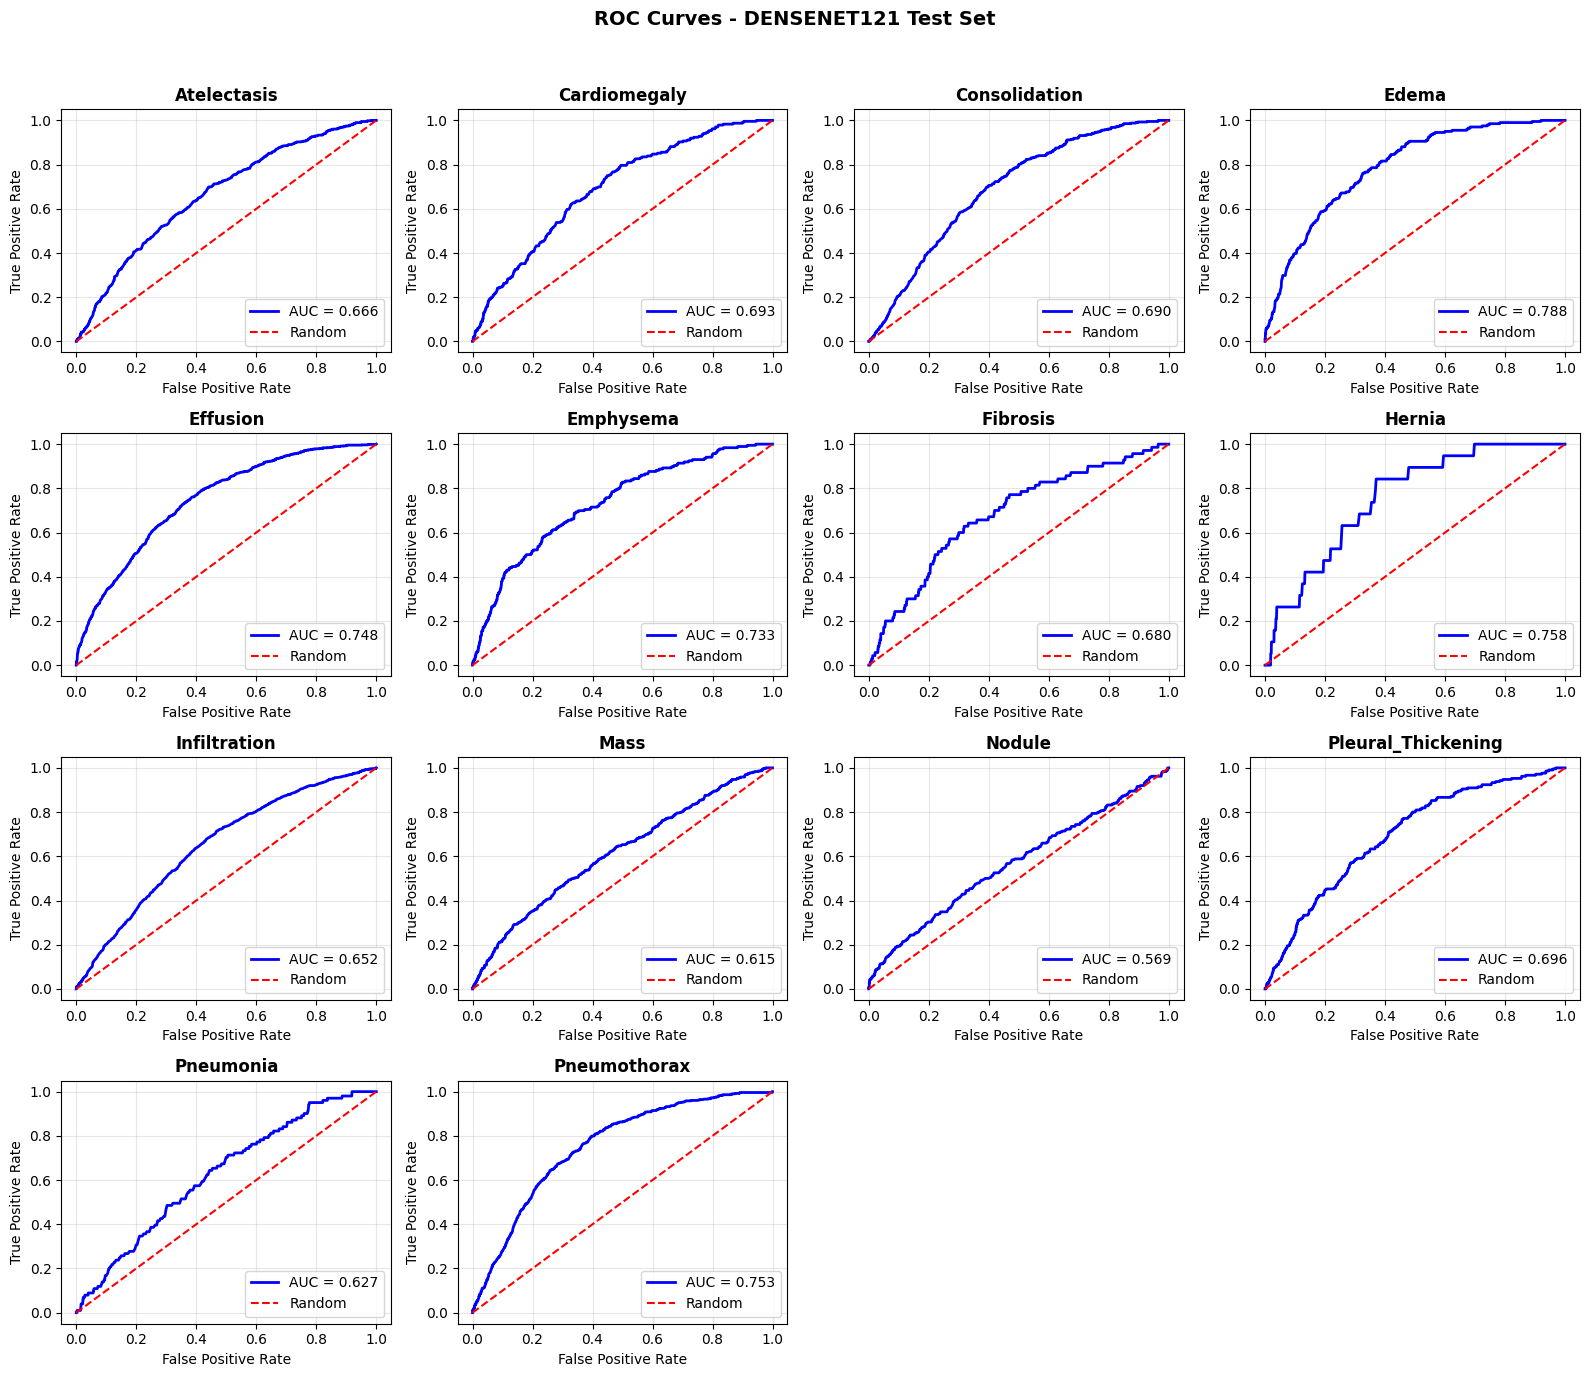

In [20]:
# Plot ROC curves
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(DISEASES):
    ax = axes[i]
    try:
        fpr, tpr, _ = roc_curve(test_true[:, i], test_preds[:, i])
        auc = roc_auc_score(test_true[:, i], test_preds[:, i])
        ax.plot(fpr, tpr, 'b-', label=f'AUC = {auc:.3f}', linewidth=2)
        ax.plot([0, 1], [0, 1], 'r--', label='Random')
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(col, fontweight='bold')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)
    except Exception as e:
        ax.text(0.5, 0.5, f'Error', ha='center', va='center')
        ax.set_title(col, fontweight='bold')

for j in range(len(DISEASES), 16):
    axes[j].axis('off')

plt.suptitle(f'ROC Curves - {MODEL_NAME.upper()} Test Set', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(ENS_DIR / f'{MODEL_KEY}_roc_curves.png', dpi=150)
plt.show()

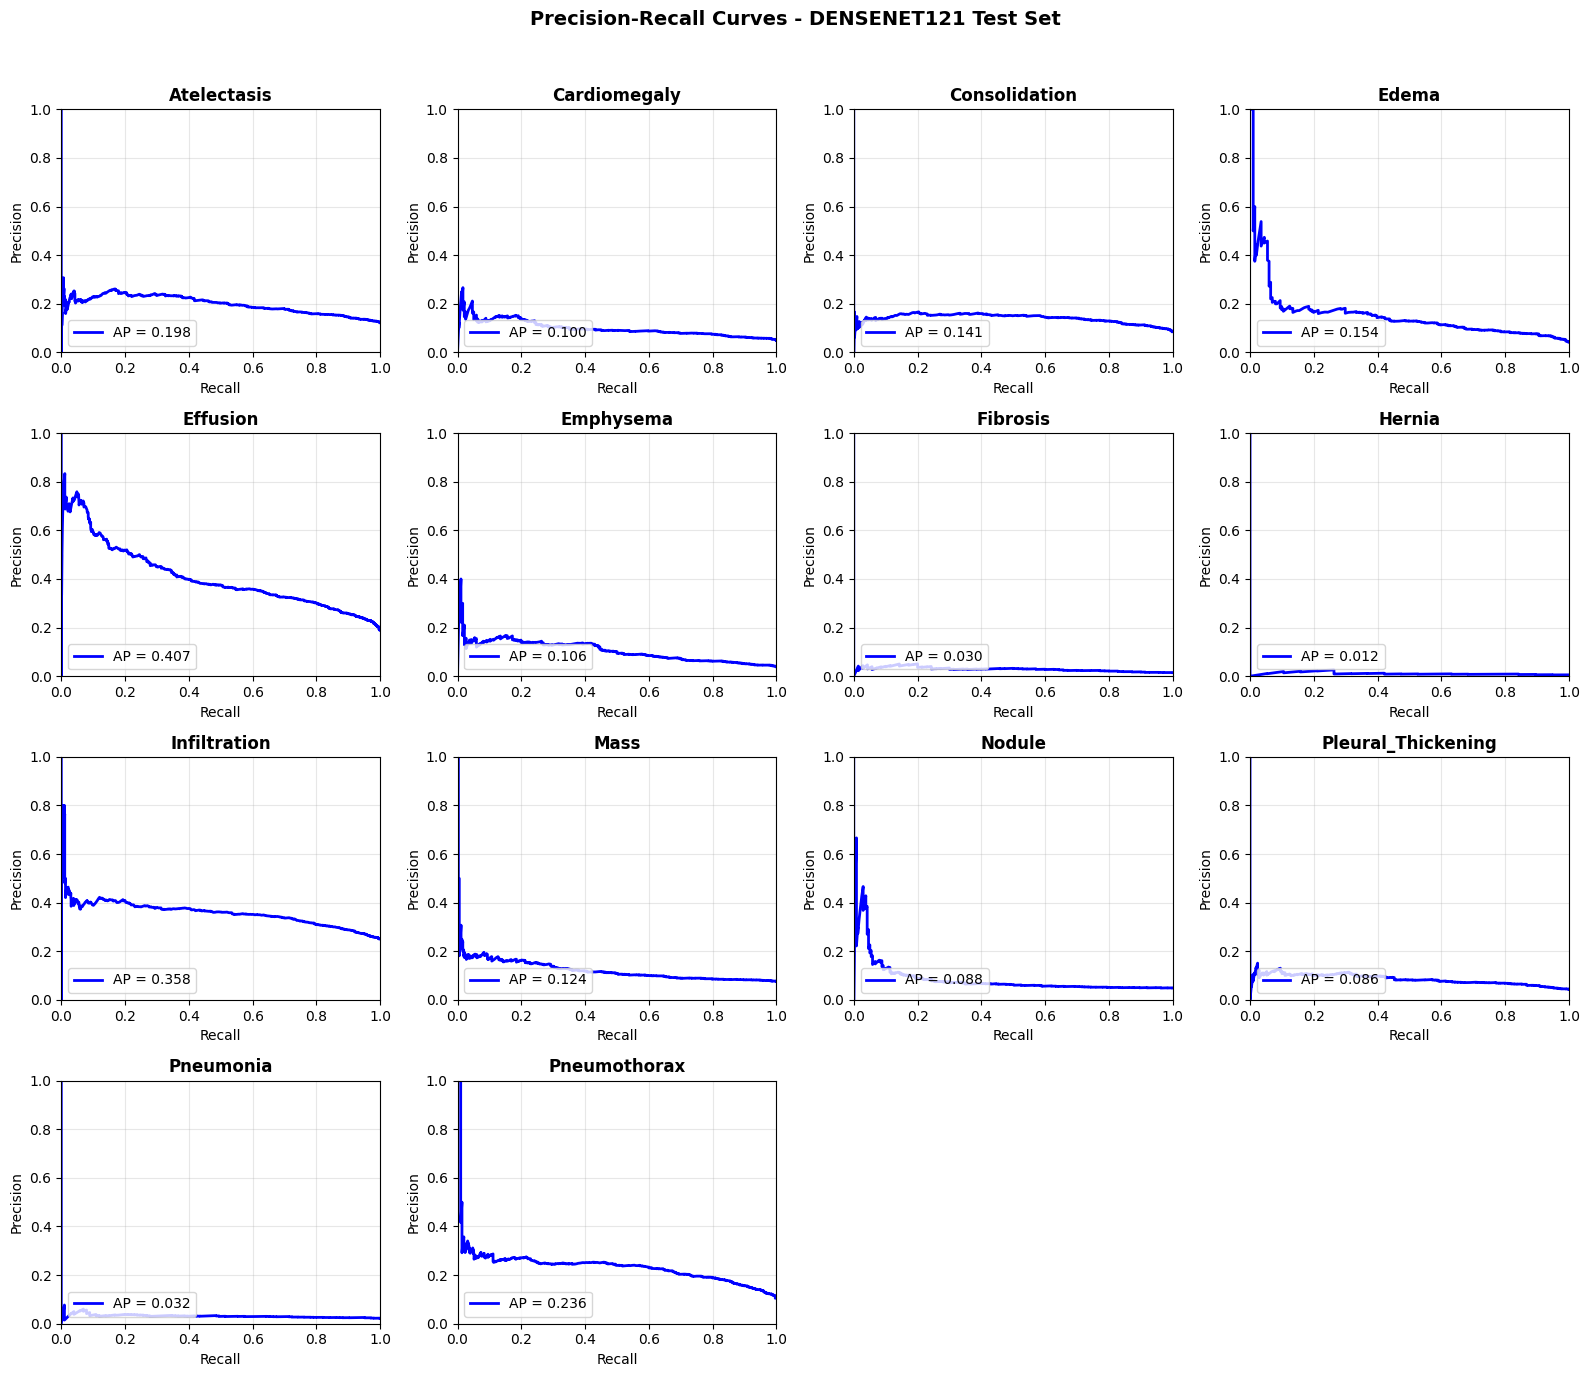

In [21]:
# Plot Precision-Recall curves
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(DISEASES):
    ax = axes[i]
    try:
        precision, recall, _ = precision_recall_curve(test_true[:, i], test_preds[:, i])
        ap = average_precision_score(test_true[:, i], test_preds[:, i])
        ax.plot(recall, precision, 'b-', label=f'AP = {ap:.3f}', linewidth=2)
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.set_title(col, fontweight='bold')
        ax.legend(loc='lower left')
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
    except Exception as e:
        ax.text(0.5, 0.5, f'Error', ha='center', va='center')
        ax.set_title(col, fontweight='bold')

for j in range(len(DISEASES), 16):
    axes[j].axis('off')

plt.suptitle(f'Precision-Recall Curves - {MODEL_NAME.upper()} Test Set', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(ENS_DIR / f'{MODEL_KEY}_pr_curves.png', dpi=150)
plt.show()

## 13. Final Summary

In [22]:
print(f'\n{"="*60}')
print(f'FINAL SUMMARY - {MODEL_NAME.upper()}')
print(f'{"="*60}')
print(f'\nModel Configuration:')
print(f'  - Architecture: DenseNet-121 (pretrained)')
print(f'  - Image size: {IMAGE_SIZE}x{IMAGE_SIZE}')
print(f'  - Preprocessing: Adaptive Lung Crop + CLAHE')
print(f'  - Loss: Focal Loss (alpha={FOCAL_ALPHA}, gamma={FOCAL_GAMMA})')
print(f'  - Label smoothing: {LABEL_SMOOTHING}')

print(f'\nTraining Results:')
print(f'  - Best mode: {best_mode_name}')
print(f'  - Best fold: {best_fold_idx}')
print(f'  - OOF Macro AUC: {best_mode_auc*100:.2f}%')

print(f'\nTest Results (Optimal Thresholds):')
print(f'  - Mean AUC: {test_optimal["AUC-ROC"].mean():.2f}%')
print(f'  - Mean F1: {test_optimal["F1-Score"].mean():.2f}%')
print(f'  - Mean Precision: {test_optimal["Precision"].mean():.2f}%')
print(f'  - Mean Recall: {test_optimal["Recall"].mean():.2f}%')

print(f'\nTest Results (Fixed Threshold 0.5):')
print(f'  - Mean F1: {test_fixed["F1-Score"].mean():.2f}%')

print(f'\nOutput files saved to: {ENS_DIR}')
print(f'{"="*60}')


FINAL SUMMARY - DENSENET121

Model Configuration:
  - Architecture: DenseNet-121 (pretrained)
  - Image size: 256x256
  - Preprocessing: Adaptive Lung Crop + CLAHE
  - Loss: Focal Loss (alpha=1.0, gamma=2.0)
  - Label smoothing: 0.1

Training Results:
  - Best mode: full_epoch
  - Best fold: 3
  - OOF Macro AUC: 71.84%

Test Results (Optimal Thresholds):
  - Mean AUC: 69.06%
  - Mean F1: 13.39%
  - Mean Precision: 19.96%
  - Mean Recall: 20.10%

Test Results (Fixed Threshold 0.5):
  - Mean F1: 1.62%

Output files saved to: /kaggle/working/output/ensemble_inputs
